In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# 1. Load Data
# We go up one level from 'notebooks' to find 'data'
data_path = os.path.join('..', 'data', 'HAM10000_metadata.csv')
df = pd.read_csv(data_path)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


In [4]:
print(df.describe())

               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


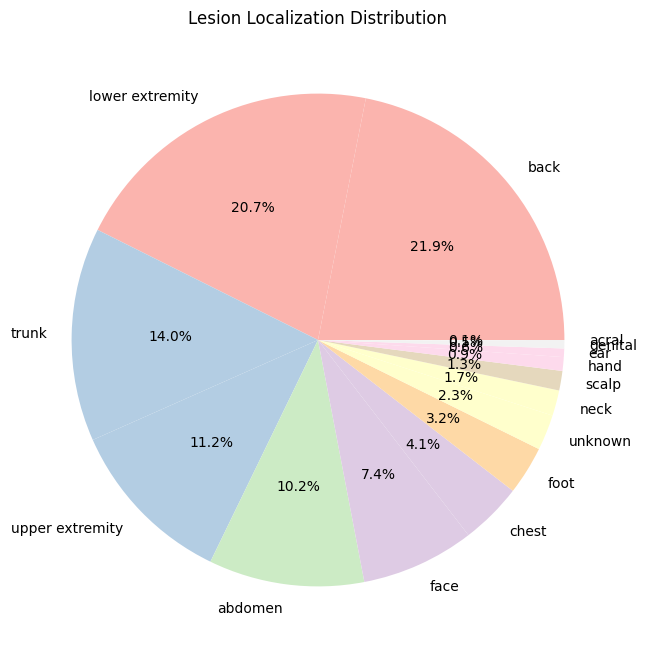

In [7]:
# 5. Localization (Where lesions are found on the body)
plt.figure(figsize=(12,8))
df['localization'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Lesion Localization Distribution')
plt.ylabel('')
plt.show()

In [8]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Total Lesions: 7470
Lesions with multiple images: 1956


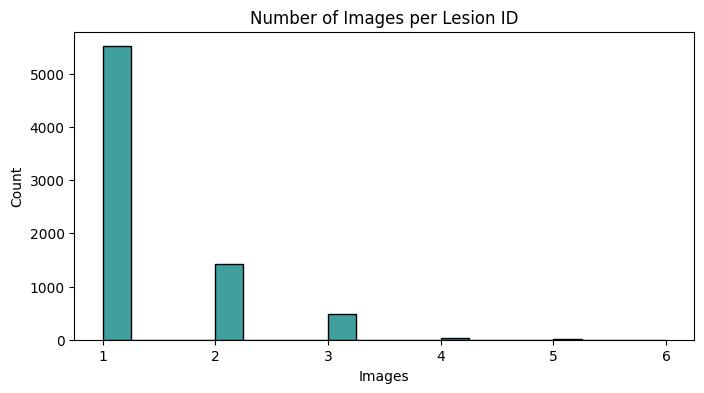

In [9]:
# Check if lesions have multiple images
lesion_counts = df.groupby('lesion_id').size()
multiple_images = lesion_counts[lesion_counts > 1]

print(f"Total Lesions: {df['lesion_id'].nunique()}")
print(f"Lesions with multiple images: {len(multiple_images)}")

# Visualize the frequency of multiple images per lesion
plt.figure(figsize=(8,4))
sns.histplot(lesion_counts, bins=20, color='teal')
plt.title('Number of Images per Lesion ID')
plt.xlabel('Images')
plt.show()

<Figure size 1500x800 with 0 Axes>

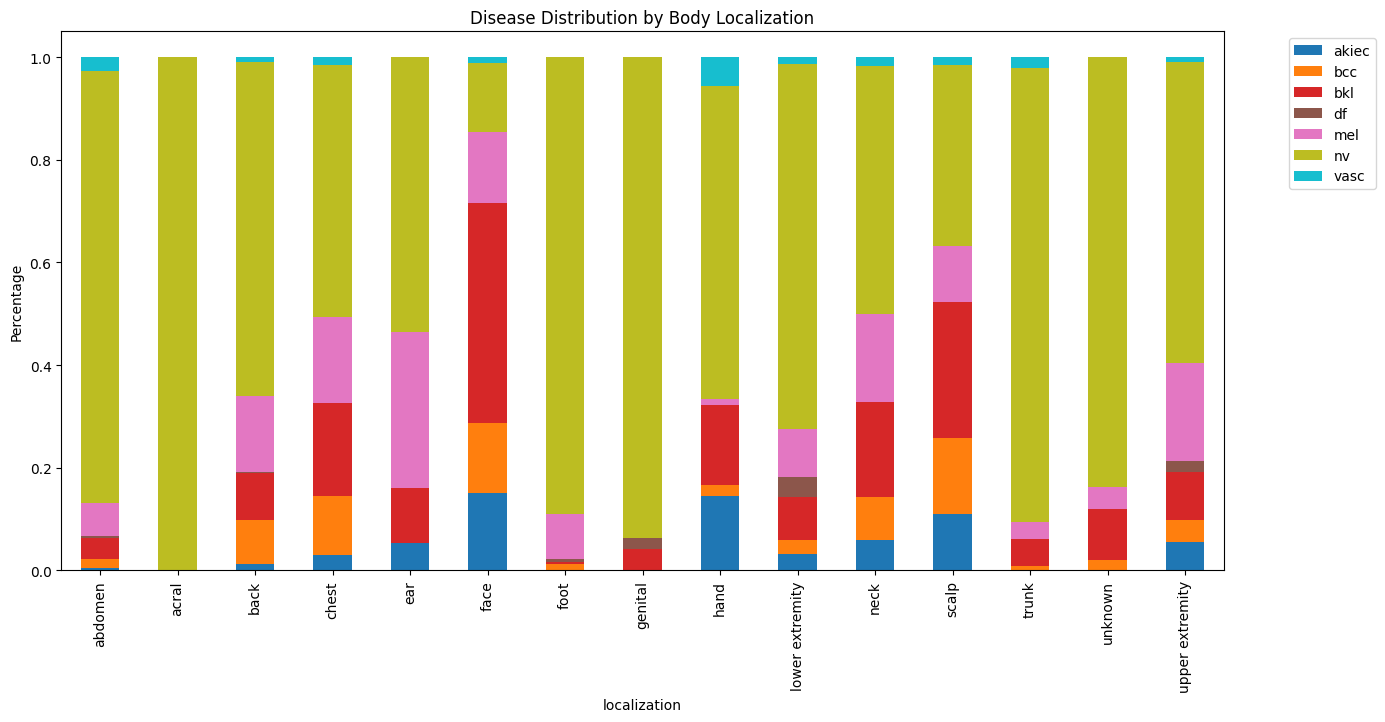

In [11]:
# Relationship between Localization and Disease
plt.figure(figsize=(15,8))
ct = pd.crosstab(df['localization'], df['dx'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(15,7), colormap='tab10')
plt.title('Disease Distribution by Body Localization')
plt.ylabel('Percentage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18140\2175204017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='dx', data=df, order=df['dx'].value_counts().index, palette='viridis')


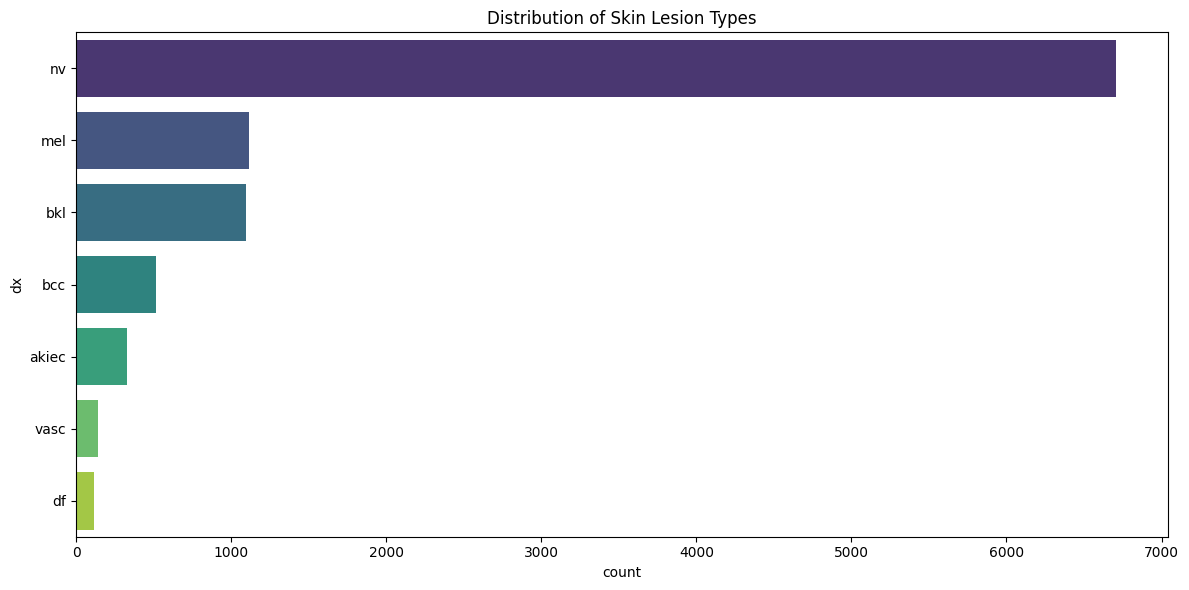

In [12]:
# --- Plot 1: Class Distribution ---
plt.figure(figsize=(12,6))
sns.countplot(y='dx', data=df, order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Skin Lesion Types')
plt.tight_layout()
plt.savefig('eda_plots/1_class_distribution.png', dpi=300) # Saves the image
plt.show()

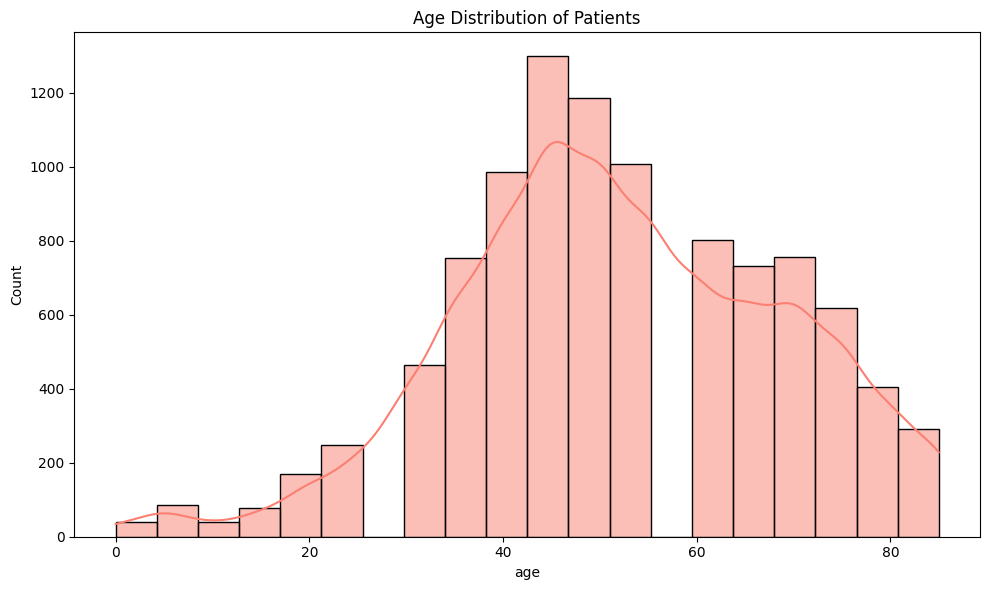

In [13]:
# --- Plot 2: Age Distribution ---
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True, color='salmon')
plt.title('Age Distribution of Patients')
plt.tight_layout()
plt.savefig('eda_plots/2_age_distribution.png', dpi=300)
plt.show()

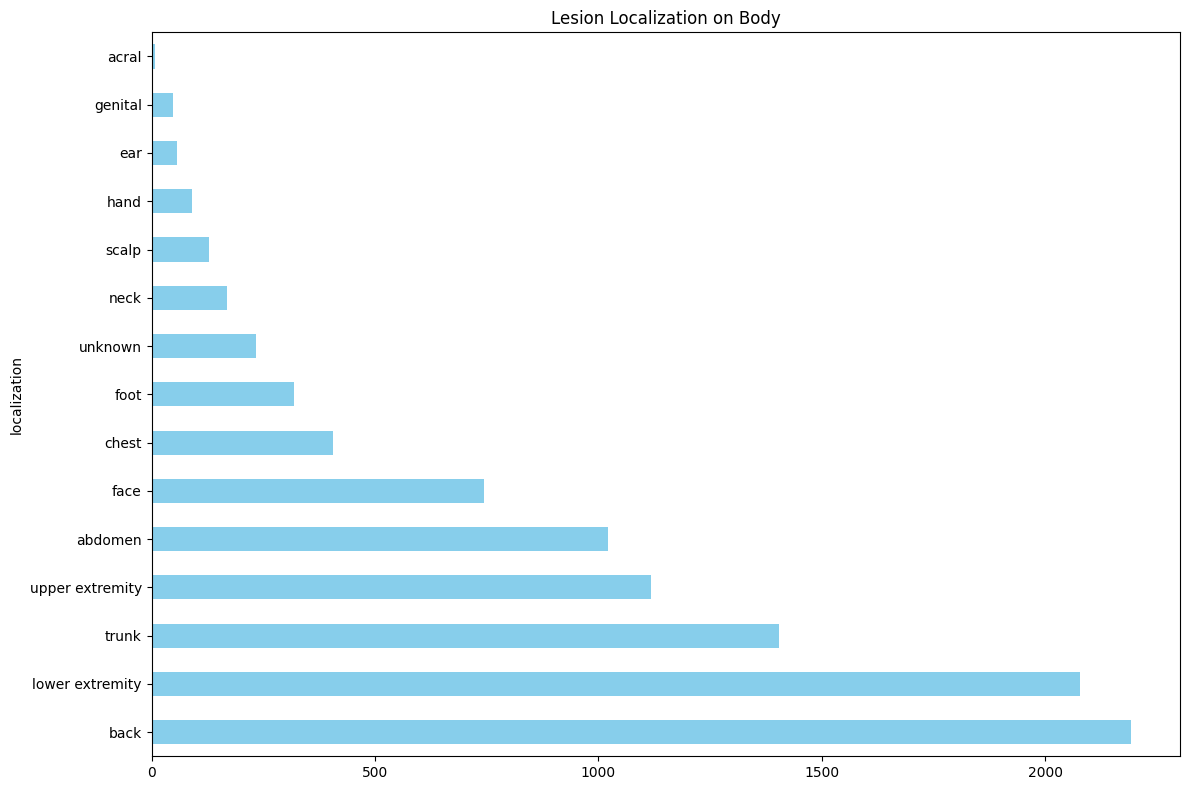

In [14]:
# --- Plot 3: Localization Heatmap ---
plt.figure(figsize=(12,8))
df['localization'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Lesion Localization on Body')
plt.tight_layout()
plt.savefig('eda_plots/3_localization_count.png', dpi=300)
plt.show()

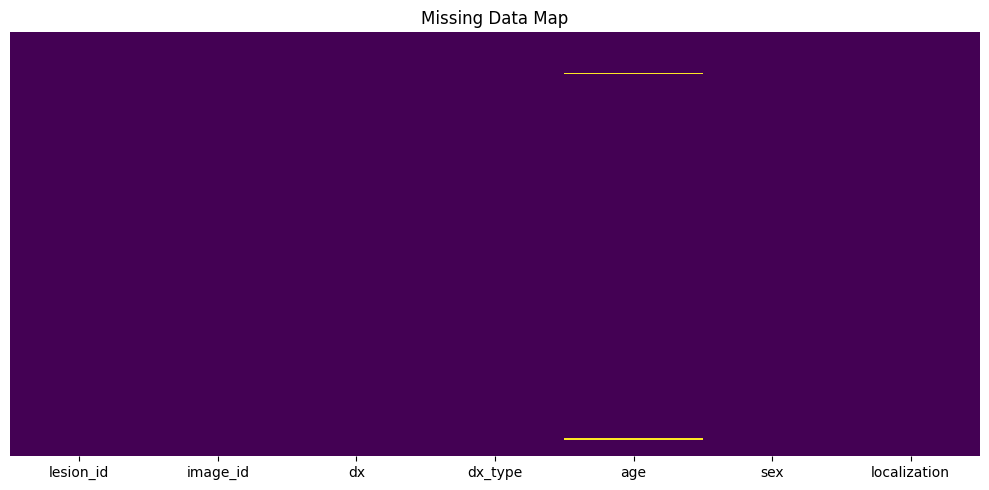

In [15]:
# --- Plot 4: Missing Data ---
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.tight_layout()
plt.savefig('eda_plots/4_missing_data_map.png', dpi=300)
plt.show()

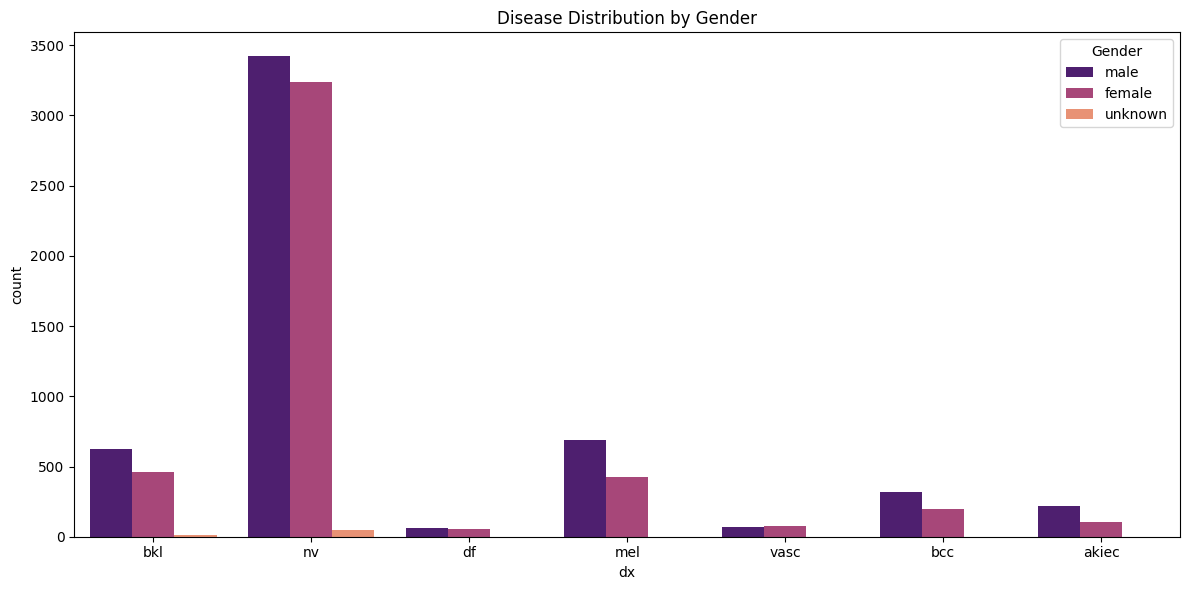

In [16]:
# --- Plot 5: Gender Distribution per Disease ---
plt.figure(figsize=(12, 6))
sns.countplot(x='dx', hue='sex', data=df, palette='magma')
plt.title('Disease Distribution by Gender')
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.savefig('eda_plots/5_gender_by_disease.png', dpi=300)
plt.show()

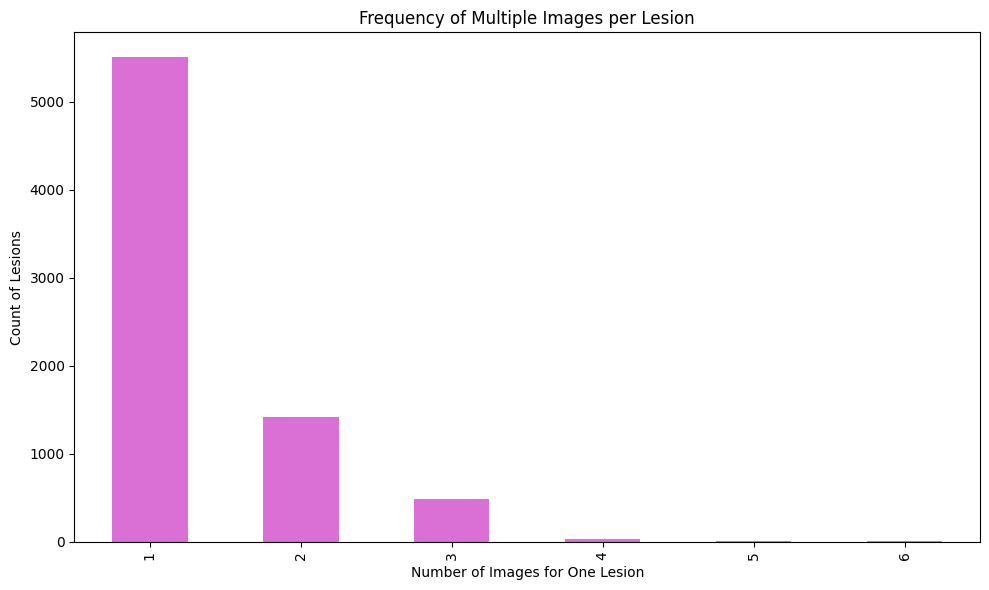

In [17]:
# --- Plot 6: Duplicate Image Analysis (Data Leakage) ---
# Counting how many images belong to the same lesion ID
lesion_freq = df['lesion_id'].value_counts().value_counts().sort_index()

plt.figure(figsize=(10, 6))
lesion_freq.plot(kind='bar', color='orchid')
plt.title('Frequency of Multiple Images per Lesion')
plt.xlabel('Number of Images for One Lesion')
plt.ylabel('Count of Lesions')
plt.tight_layout()
plt.savefig('eda_plots/6_data_leakage_check.png', dpi=300)
plt.show()

In [18]:
# 1. Fill missing age values with the mean
df['age'].fillna(df['age'].mean(), inplace=True)

# 2. Check for missing values again to confirm
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_18140\3030396646.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


In [21]:
# 3. Handle Data Leakage (The "Cheat" Check)
# We want to keep only one image per lesion_id to ensure a clean split 
# or ensure that images of the same lesion are kept in the same split.
# Strategy: Drop duplicates for a simple, clean training set
df_unique = df.drop_duplicates(subset='lesion_id', keep='first')

print(f"\nOriginal images: {len(df)}")
print(f"Unique lesions (cleaned): {len(df_unique)}")

# 4. Save the cleaned metadata
df_unique.to_csv('../data/HAM10000_cleaned.csv', index=False)


Original images: 10015
Unique lesions (cleaned): 7470


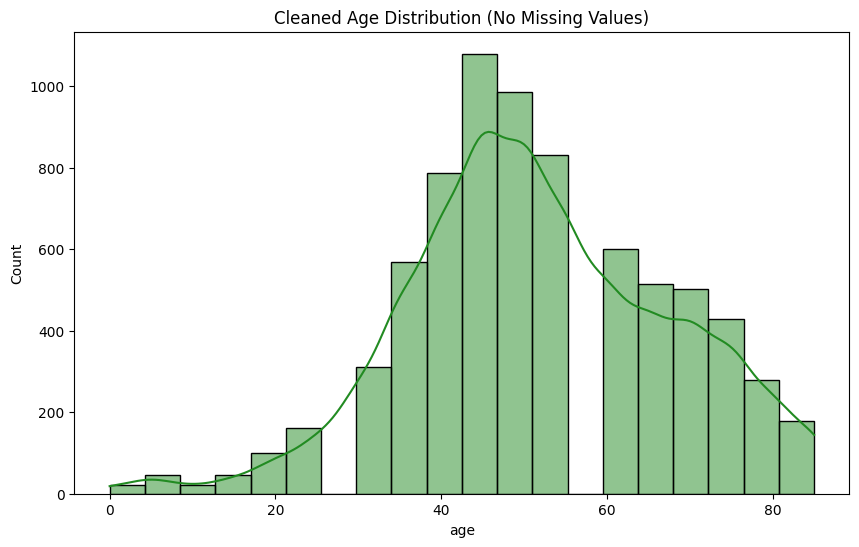

In [22]:
# --- Plot 7: Cleaned Age Distribution ---
plt.figure(figsize=(10,6))
sns.histplot(df_unique['age'], bins=20, kde=True, color='forestgreen')
plt.title('Cleaned Age Distribution (No Missing Values)')
plt.savefig('eda_plots/7_cleaned_age_dist.png', dpi=300)
plt.show()

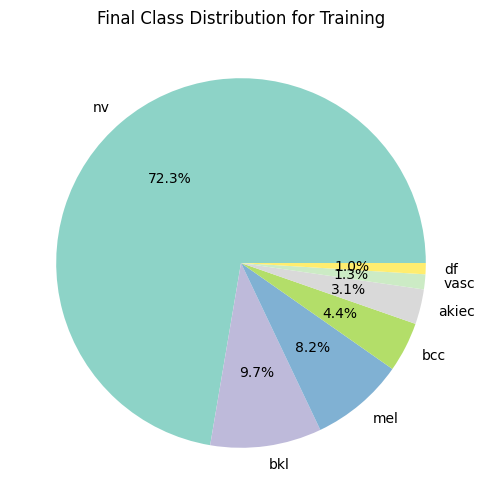

In [23]:
# --- Plot 8: Cleaned Class Balance ---
plt.figure(figsize=(12,6))
df_unique['dx'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set3')
plt.title('Final Class Distribution for Training')
plt.ylabel('')
plt.savefig('eda_plots/8_final_class_pie.png', dpi=300)
plt.show()

In [32]:
import os
import sys

# 1. Get the current directory (where the notebook is)
notebook_dir = os.getcwd()

# 2. Define the root path (going up one level from 'notebooks')
BASE_PATH = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Define the other paths relative to BASE_PATH
DATA_DIR = os.path.join(BASE_PATH, 'Data')
IMAGE_DIR = os.path.join(DATA_DIR, 'all_images')
METADATA_CSV = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')

# 4. Add 'src' to your system path so you can import preprocess
SRC_DIR = os.path.join(BASE_PATH, 'src')
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

print(f"Root Folder: {BASE_PATH}")
print(f"Checking for Metadata: {os.path.exists(METADATA_CSV)}")

Root Folder: c:\Users\HP\OneDrive\Desktop\Skin_Cancer_Detection
Checking for Metadata: True


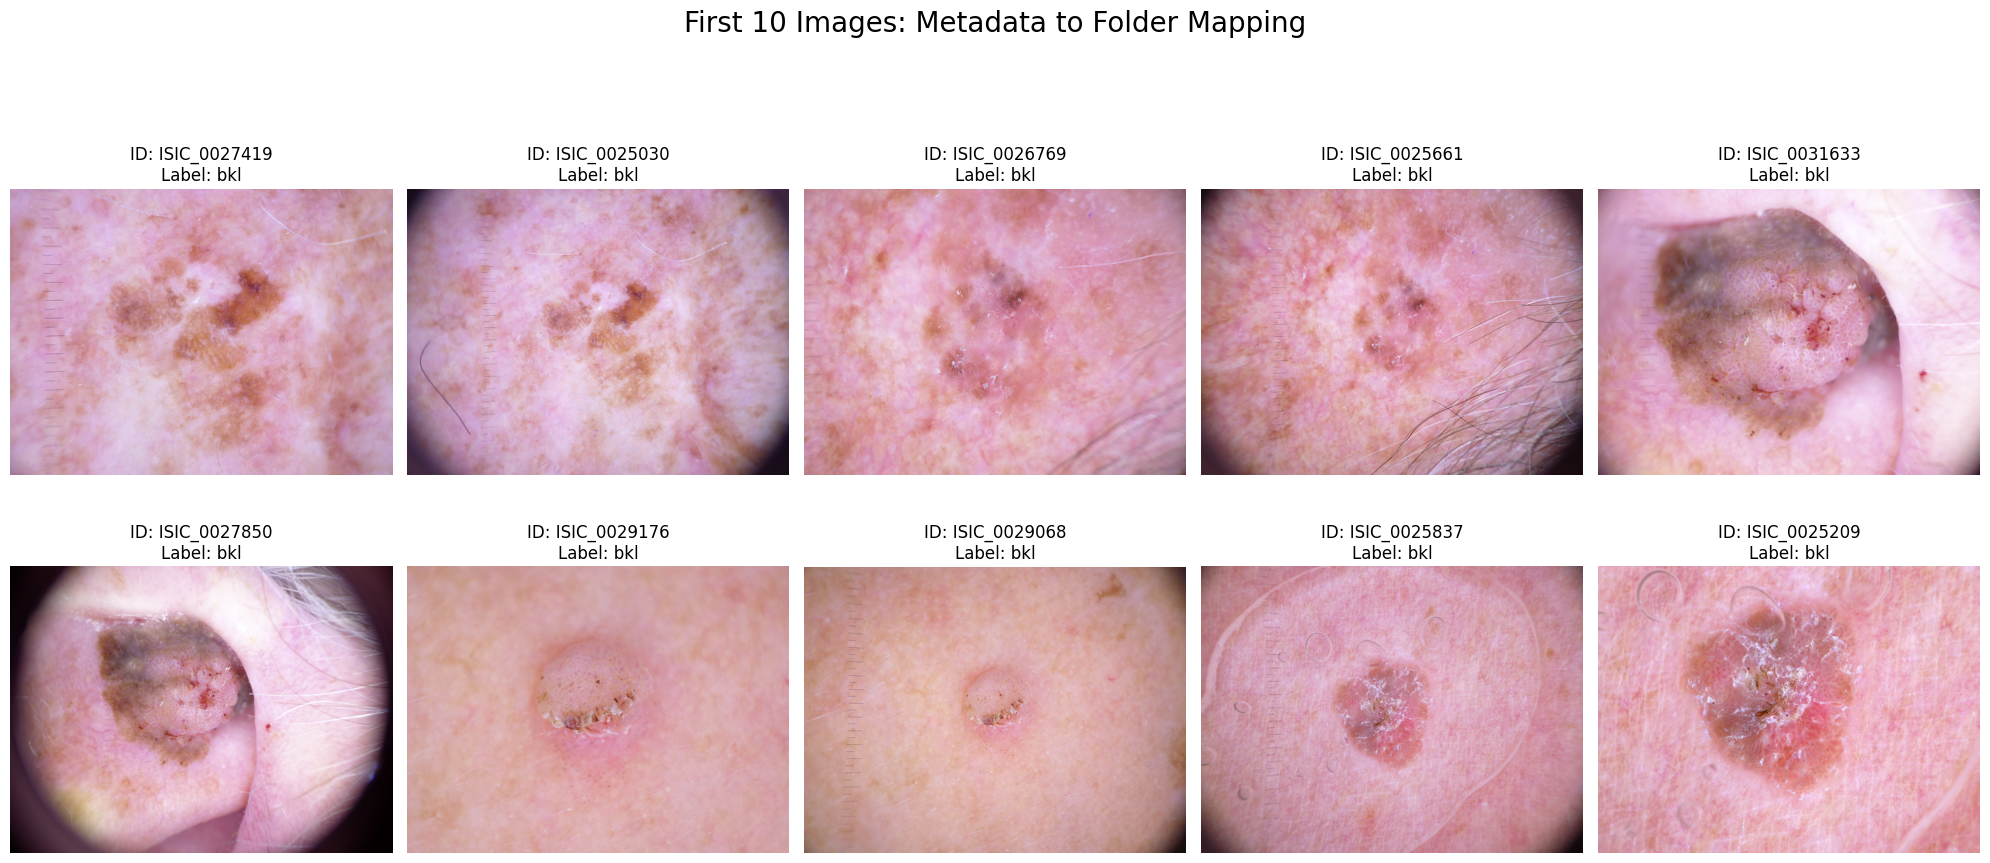

In [34]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the metadata
df = pd.read_csv(METADATA_CSV)

# 2. Setup the visualization grid (2 rows, 5 columns)
plt.figure(figsize=(20, 10))
plt.suptitle("First 10 Images: Metadata to Folder Mapping", fontsize=20)

# 3. Loop through the first 10 rows of the CSV
for i in range(10):
    img_id = df.iloc[i]['image_id']
    dx = df.iloc[i]['dx']  # The diagnosis/label
    
    # Construct the image path
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")
    
    plt.subplot(2, 5, i + 1)
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"ID: {img_id}\nLabel: {dx}", fontsize=12)
    else:
        # If the image is missing, show a placeholder
        plt.text(0.5, 0.5, f"MISSING\n{img_id}", ha='center', va='center', color='red')
        plt.title(f"ID: {img_id} (NOT FOUND)", color='red')
        
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [35]:
import os

# Using the paths we defined earlier
sample_id = "ISIC_0024306"
expected_path = os.path.join(IMAGE_DIR, f"{sample_id}.jpg")

if os.path.exists(expected_path):
    print(f"✅ Success! Found image at: {expected_path}")
else:
    print(f"❌ Error: Could not find {sample_id}.jpg in {IMAGE_DIR}")
    # Let's list what IS actually in there to troubleshoot
    print("Files currently in folder:", os.listdir(IMAGE_DIR)[:5])

✅ Success! Found image at: c:\Users\HP\OneDrive\Desktop\Skin_Cancer_Detection\Data\all_images\ISIC_0024306.jpg


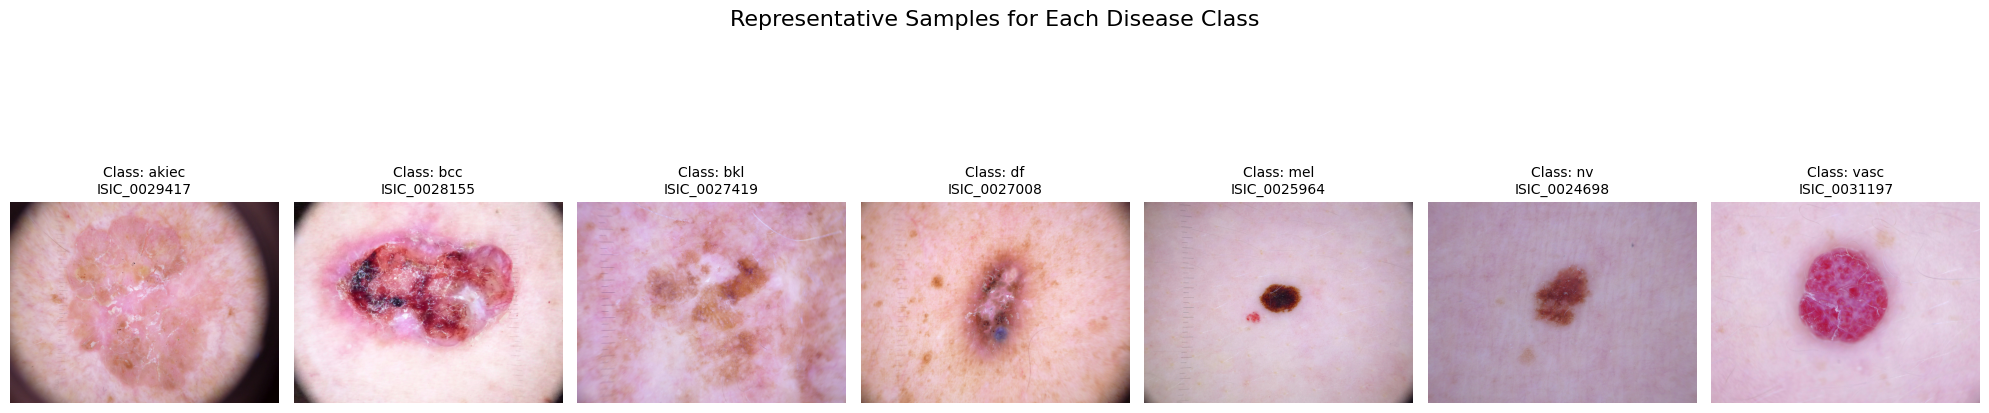

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Load the metadata
df = pd.read_csv(METADATA_CSV)

# 2. Get the first image ID for each unique class
# This creates a small dataframe with 7 rows, one for each 'dx'
sample_df = df.groupby('dx').first().reset_index()

# 3. Create the display grid
plt.figure(figsize=(20, 5))
plt.suptitle("Representative Samples for Each Disease Class", fontsize=16, y=1.05)

for i, row in sample_df.iterrows():
    dx_type = row['dx']
    img_id = row['image_id']
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")
    
    plt.subplot(1, 7, i + 1)
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Class: {dx_type}\n{img_id}", fontsize=10)
    else:
        plt.text(0.5, 0.5, "Missing", ha='center', va='center')
        plt.title(f"{dx_type} (Not Found)")
        
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

In [ ]:
import os
import pandas as pd

# 1. Start from the current notebook directory
current_dir = os.getcwd()

# 2. Go up one level to the root 'skin_cancer_detection' folder
root_dir = os.path.abspath(os.path.join(current_dir, '..'))

# 3. Join with the specific Data folder and file name
# Note: Ensure 'Data' starts with a capital 'D' if that's how it's named!
metadata_path = os.path.join(root_dir,'Data', 'HAM10000_metadata.csv')

print(f"Searching at: {metadata_path}")

df1 = pd.read_csv(metadata_path)
print("✅ Success! Metadata loaded.")
display(df1.tail())


Searching at: c:\Users\HP\OneDrive\Desktop\Skin_Cancer_Detection\Data\HAM10000_metadata.csv
✅ Success! Metadata loaded.


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back,vidir_modern
